# __Le réchauffement climatique__ - Ben Lichtfeld SPRINTB

## __Introduction__
  
Nous cherchons à déterminer si les relevés de température enregistrés depuis __1920 à la station météorologique de Montélimar mettent en évidence un réchauffement significatif__. Les données proviennent de l’__ECAD__ et contiennent la __date (MJD)__ et la __température (°C)__.  
 
Pour analyser ces données, nous utiliserons d'abord un __modèle sinusoïdal__ pour représenter les variations saisonnières. Nous effecturons ensuite un ajustement par décennies pour pour observer l’évolution de la température moyenne. Nous utiliserons enfin un __modèle sinusoïdal avec tendance linéaire__ pour quantifier l’accroissement de la température au fil du temps.
L’incertitude des mesures sera prise en compte pour montrer que l'effet observé est significatif.

## __1. Eléments théoriques__

#### __Modèle sinusoïdal__  

L’objectif est d’analyser l’évolution des températures enregistrées à Montélimar depuis 1920 afin de détecter une éventuelle tendance au réchauffement. Les températures présentent des fluctuations **journalières** et **saisonnières**, rendant difficile la mise en évidence d’un effet lent et progressif.  

Nous utiliserons un **modèle sinusoïdal** pour représenter les variations annuelles de température :  
$$
T(t) = A \sin(\omega t + \phi) + B
$$
où :
- $A$ est l’amplitude des variations saisonnières.
- $ \omega = 2\pi / 1$ an est la fréquence associée à une période d’un an.
- $\phi$ est la phase.  
- $B$ représente la température moyenne sur la période analysée.  

Nous ajusterons ces différents paramètres aux données

Cependant, ce modèle seul ne permet pas de mettre en évidence une **tendance à long terme**.  

#### __Modèle avec tendance linéaire__  
Pour prendre en compte un éventuel réchauffement climatique, nous ajouterons un **terme de croissance linéaire** :  
$$
T(t) = A \sin(\omega t + \phi) + B + C t
$$
où **$ C $** représente la tendance à l’augmentation de la température en fonction du temps.  

L’ajustement des paramètres **($ A, \phi, B, C $)** sera réalisé à l’aide de la méthode des **moindres carrés non linéaires** via la fonction `curve_fit`. Cela nous permettra également d’estimer l’incertitude associée à chaque paramètre et de statuer sur la **significativité du réchauffement observé**.

## __2. Hypothèses__

Nous faisons l'hypothèse que la température moyenne annuelle à Montélimar a augmenté de manière significative depuis 1920. Cette augmentation pourrait être due au réchauffement climatique global observé à l'échelle mondiale. Nous supposons également que les relevés de température sont suffisamment précis pour permettre une analyse pertinente sur une longue période.

On définit donc deux modèles comme vu précédemment.
On importe les bibliothèques nécessaires à notre projet.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## __3. Modélisation__
### __3.1. Modèle sinusoïdal__ 

On lit la data.

In [22]:
data = np.loadtxt('montelimar_temperature.dat')
t_MJD = data[:, 0]
temperature = data[:, 1]

#conversion des mjd en années à partir de 1920

annees = (t_MJD - t_MJD[0]) / 365.25
debut_annee = 1920 
t_annees = annees + debut_annee

On trace le graphe des données brutes.

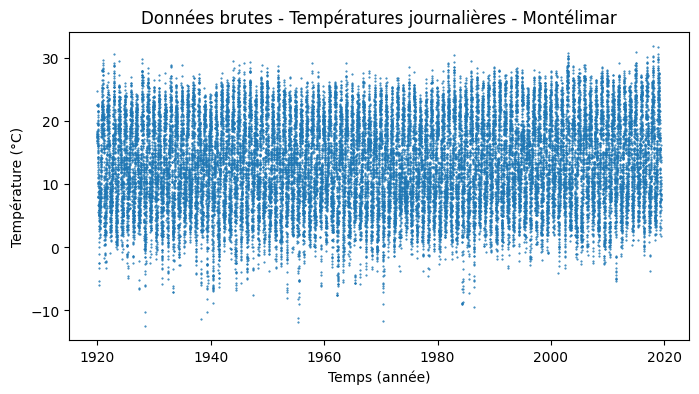

In [23]:
plt.figure(figsize=(8,4))
plt.plot(t_annees, temperature, '.', markersize=1)
plt.xlabel('Temps (année)')
plt.ylabel('Température (°C)')
plt.title('Données brutes - Températures journalières - Montélimar')
plt.show()

On modélise donc le phénomène avec le modéle sinusoïdal.

In [24]:
#modèle
def model_sinusoidal(t_annees, A, phi, B):
    omega = 2*np.pi #période de 1an
    T = A*np.sin(omega*t_annees + phi) + B
    return T

On fait ensuite un curve_fit pour déterminer les paramètres optimaux.

In [25]:
#ajustement du modèle linéaire
params, pcov = curve_fit(model_sinusoidal, t_annees, temperature)

# Récupération des incertitudes à partir de la matrice de covariance
perr = np.sqrt(np.diag(pcov))

#affichage des valeurs des paramètres et des incertitudes
amplitude = params[0]
d_amplitude = perr[0]
phase = params[1]
d_phase = perr[1]
temperature_moyenne =  params[2]
d_temperature_moyenne = perr[2]

print(f"A = {amplitude:.3f} ± {perr[0]:.3f} °C")
print(f"phi = {phase:.3f} ± {perr[1]:.3f}")
print(f"B = {temperature_moyenne:.3f} ± {perr[2]:.3f} °C")

A = 9.011 ± 0.024 °C
phi = 8.320 ± 0.003
B = 13.368 ± 0.017 °C


On trace ensuite le graphe de ce modèle avec le modèle brute par dessous.

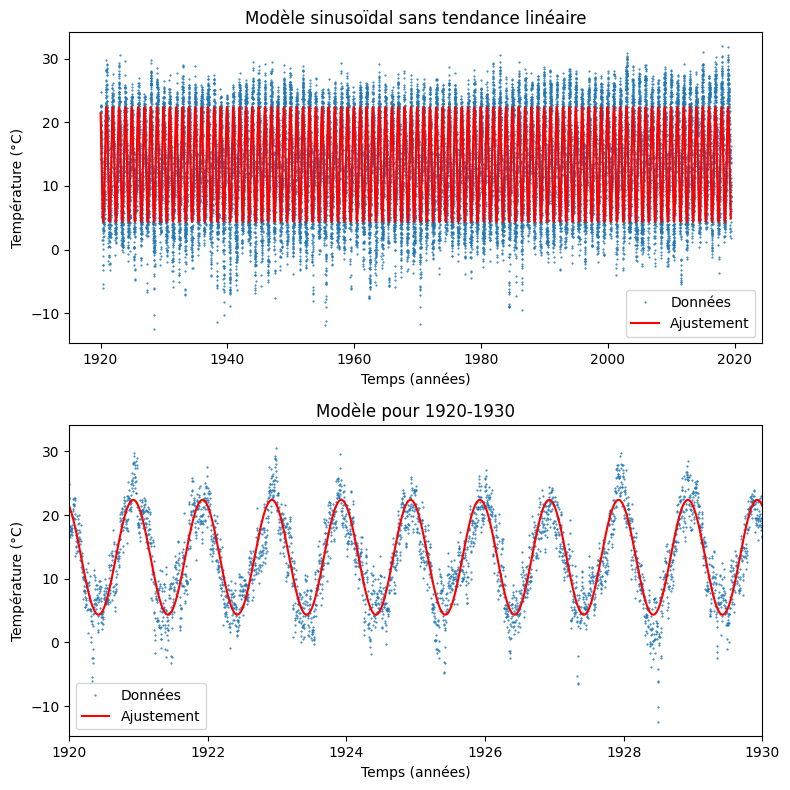

In [26]:
#calcul du modèle
t_model = np.linspace(min(t_annees), max(t_annees), 10000)
temperature_model = model_sinusoidal(t_model, amplitude, phase , temperature_moyenne)

#tracé du graphe

fig, axes = plt.subplots(2, 1, figsize=(8, 8))

#graphe complet
axes[0].plot(t_annees, temperature, '.', markersize=1, label="Données")
axes[0].plot(t_model, temperature_model, 'r-', label="Ajustement")
axes[0].set_xlabel("Temps (années)")
axes[0].set_ylabel("Température (°C)")
axes[0].set_title("Modèle sinusoïdal sans tendance linéaire")
axes[0].legend()

#graphe sur 1920-1930
axes[1].plot(t_annees, temperature, '.', markersize=1, label="Données")
axes[1].plot(t_model, temperature_model, 'r-', label="Ajustement")
axes[1].set_xlabel("Temps (années)")
axes[1].set_ylabel("Température (°C)")
axes[1].set_title("Modèle pour 1920-1930")
axes[1].set_xlim(1920, 1930)
axes[1].legend()

plt.tight_layout()
plt.show()

L'ajustement d'un modèle sinusoïdal sur l'ensemble des données permet d'extraire des paramètres représentatifs des variations saisonnières. Cependant, ce modèle seul ne permet pas de mettre en évidence une tendance à long terme.
Puisque ce modèle ne donnera aucune augmentation moyenne de la température, on va appliquer un ajustement sinusoïdal pour chaque décennie, et voir si le paramètre 𝐵 (température moyenne) augmente. On estime que l'erreur sur les mesures de température est de l'ordre de 5 °C (à expliquer par calcul).

In [27]:
decennies = np.arange(1920, 2030,10)
nb_decennies = len(decennies) - 1

temperature_moyenne_decennie = []
milieu_decennie = []  
erreur_moyenne_decennie = []
#boucle sur chaque décennie
for i in range(nb_decennies):
    t_decennie = []
    temperature_decennie = []
    
    #sélection des dates des données entre 1920 et 2020
    for j in range(len(t_annees)):
        if decennies[i] <= t_annees[j] < decennies[i + 1]:
            t_decennie.append(t_annees[j])
            temperature_decennie.append(temperature[j])

    #conversion en tableau numpy
    t_decennie = np.array(t_decennie)
    temperature_decennie = np.array(temperature_decennie)
    
    #ajustement de B
    params, pcov = curve_fit(model_sinusoidal, t_decennie, temperature_decennie)
    B_decennie = params[2]  #température moyenne ajustée
    temperature_moyenne_decennie.append(B_decennie)
    milieu_decennie.append((decennies[i] + decennies[i + 1]) / 2)#milieu de la décennie
    
    #incertitude
    erreur_moyenne = 5 / np.sqrt(len(t_decennie)) 
    erreur_moyenne_decennie.append(erreur_moyenne)

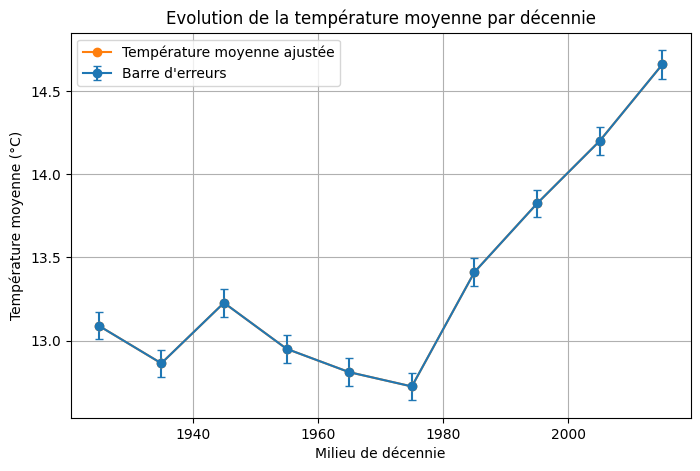

In [28]:
plt.figure(figsize=(8,5))
plt.errorbar(milieu_decennie, temperature_moyenne_decennie, yerr=erreur_moyenne_decennie, fmt='o-',label="Barre d'erreurs", capsize=3)
plt.plot(milieu_decennie, temperature_moyenne_decennie, 'o-',label="Température moyenne ajustée")
plt.xlabel("Milieu de décennie")
plt.ylabel("Température moyenne (°C)")
plt.title("Evolution de la température moyenne par décennie")
plt.legend()
plt.grid()
plt.show()

On observe donc que la moyenne de la température augmente à partir d'environ 1975.

### __3.2. Modèle avec tendance linéaire__ 

On définit alors un auitre modèle comme vu dans la partie théorique.

In [29]:
#modèle
def model_sinusoidal_lin(t_annees, A, phi, B, C):
    omega = 2*np.pi #période de 1an
    T = A*np.sin(omega*t_annees + phi) + B + C*t_annees
    return T

In [30]:
#ajustement
params2, pcov2 = curve_fit(model_sinusoidal_lin, t_annees, temperature)
A2, phi2, B2, C2 = params2
perr2 = np.sqrt(np.diag(pcov2))

print(f"A = {A2:.3f} ± {perr2[0]:.3f} °C")
print(f"phi = {phi2:.3f} ± {perr2[1]:.3f}")
print(f"B = {B2:.3f} ± {perr2[2]:.3f} °C")
print(f"C = {C2:.5f} ± {perr2[3]:.5f} °C/an")

#variation de la temperature estimée sur 100 ans 
delta_100_ans = C2 * 100
print(f"Variation estimée sur 100 ans : {delta_100_ans:.2f} °C")

A = 9.009 ± 0.024 °C
phi = 8.320 ± 0.003
B = -19.848 ± 1.146 °C
C = 0.01686 ± 0.00058 °C/an
Variation estimée sur 100 ans : 1.69 °C


On voit bien que le réchauffement climatique a un impact significatif.

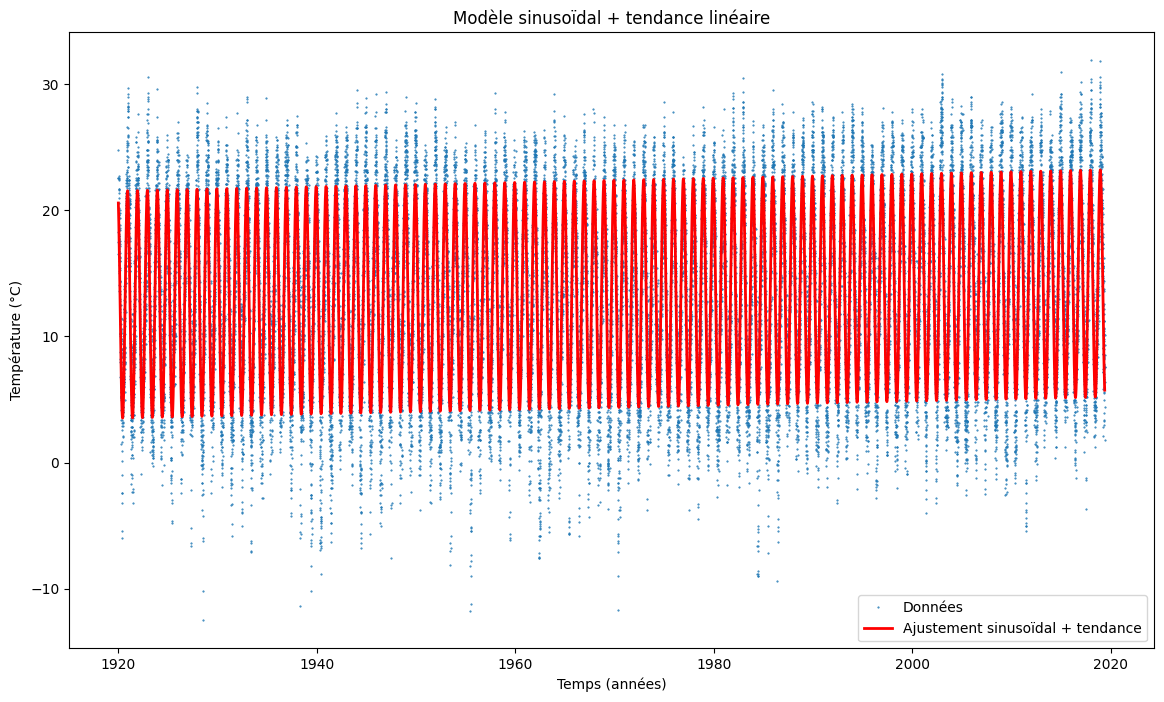

In [31]:
#graphe avec tendance linéaire
temperature_model2 = model_sinusoidal_lin(t_model, A2, phi2, B2, C2)

#graphe
plt.figure(figsize=(14,8))
plt.plot(t_annees, temperature, '.', markersize=1, label='Données')
plt.plot(t_model, temperature_model2, 'r-', linewidth=2, label='Ajustement sinusoïdal + tendance')
plt.xlabel("Temps (années)")
plt.ylabel("Température (°C)")
plt.title("Modèle sinusoïdal + tendance linéaire")
plt.legend()
plt.show()

L'ajout d'un terme de tendance linéaire au modèle sinusoïdal permet de quantifier directement l'évolution de la température sur l'ensemble de la période étudiée.

L'ajustement du modèle montre une pente positive significative, ce qui indique que la température moyenne a augmenté de manière constante depuis 1920, confirmant notre hypothèse initiale d'un réchauffement climatique à Montélimar.

## __Conclusion__

L'étude des températures enregistrées à Montélimar depuis 1920 met en évidence une augmentation significative de la température moyenne, en particulier à partir des années 1970. L'utilisation d'un modèle sinusoïdal par décennies a montré une évolution progressive du paramètre B, tandis que le modèle avec tendance linéaire a confirmé une hausse globale des températures.